<a href="https://colab.research.google.com/github/Erjg1012/predicci-n-de-permanencia-de-clientes/blob/main/predicci%C3%B3n_de_permanencia_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Máquinas de vectores de soporte empleando la base de datos de telco


El conjunto de datos que utilizaremos se llama telco.csv y proviene del sector de las telecomunicaciones. El objetivo del proyecto es predecir si el cliente permanecerá en la empresa o la abandonará. Teniendo buenos resultados en predecir si continuará. Se emplearon diversos algoritmos de clasificación de aprendizaje automático para realizar estas predicciones, y el resultado final se mostró mediante un panel de Tableau y una aplicación web implementada con Herokup.

El conjunto de datos que se utilizará en esta sesión es un archivo CSV llamado telco.csv, que contiene datos sobre la pérdida de clientes de telecomunicaciones y algunos de sus comportamientos clave. Contiene las siguientes columnas:

**Características**:

- customerID: Identificador único del cliente.
- gender: Sexo del cliente.
- SeniorCitizen: Variable binaria que indica si el cliente es una persona mayor.
- Partner: Variable binaria si el cliente tiene pareja.  
- Dependents: Variable binaria si el cliente tiene dependientes.
- tenure: Número de semanas como cliente.
- PhoneService: Si el cliente tiene servicio telefónico.
- MultipleLines: Si el cliente tiene varias líneas.
- InternetService: Tipo de servicio de internet del cliente ("DSL", "Fibra óptica", "No").
- OnlineSecurity: Si el cliente tiene servicio de seguridad en línea.
- OnlineBackup: Si el cliente tiene servicio de respaldo en línea.
- DeviceProtection: Si el cliente tiene servicio de protección de dispositivos.
- TechSupport: Si el cliente tiene servicio de soporte técnico.
- StreamingTV: Si el cliente tiene servicio de TV en streaming.
- StreamingMovies: Si el cliente tiene servicio de películas en streaming.
- Contract: Tipo de contrato del cliente ("Mes a mes", "Un año", "Bienes").
- PaperlessBilling: Si la facturación electrónica está habilitada.
- PaymentMethod: Método de pago.
- MonthlyCharges: Importe de los cargos mensuales en $.
- TotalCharges: Cantidad total de cargos hasta el momento.

 **Variable objetivo:**
- Churn: si el cliente “se quedó” o “se fue”.

Se realizaron varios pasos para aumentar la precisión del modelo y se utilizaron algoritmos de aprendizaje automático de clasificación para predecir los resultados.

#Importación de librearías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif



# Cargar los datos


In [ ]:
df = pd.read_csv('telco.csv')
df

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,Stayed
7039,7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,Stayed
7040,7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,Stayed
7041,7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Churned


In [ ]:
print(df['Churn'].value_counts())

Churn
Stayed     5174
Churned    1869
Name: count, dtype: int64


Se puede observar que los datos están desbalanceados y la mayoría se queda.

# Preprocesamiento

In [ ]:
# Eliminar columnas no relevantes como CustomerID
df = df.drop('customerID', axis=1, errors='ignore')

# Convertir variables categóricas a numéricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Churn')  # Esta es nuestra variable objetivo

for col in categorical_cols:
    if df[col].nunique() == 2:
        # Codificación binaria
        df[col] = LabelEncoder().fit_transform(df[col])
    else:
        # One-hot encoding para variables con múltiples categorías
        df = pd.get_dummies(df, columns=[col], prefix=col)

# Convertir la variable objetivo a binaria
df['Churn'] = LabelEncoder().fit_transform(df['Churn'])

# Separar en características (X) y variable objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM con kernel lineal


SVM con Kernel Lineal:
Precisión: 0.7638

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.56      0.60      0.58       574
           1       0.85      0.83      0.84      1539

    accuracy                           0.76      2113
   macro avg       0.70      0.71      0.71      2113
weighted avg       0.77      0.76      0.77      2113


Matriz de Confusión:


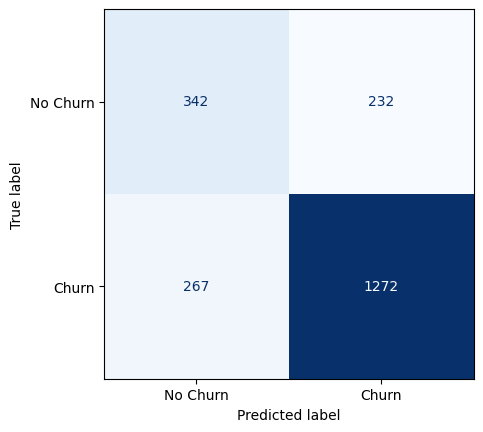

In [ ]:
# Entrenamiento del modelo SVM (kernel lineal)
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# Predicciones
y_pred = svm_linear.predict(X_test_scaled)

# Evaluación
print("SVM con Kernel Lineal:")
print(f"Precisión: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión con etiquetas personalizadas (Churn / No Churn)
print("\nMatriz de Confusión:")
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues',
    colorbar=False
)
plt.show()

# Buscar el mejor kernel y parámetros


In [ ]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    print(f"\n=== Kernel: {kernel} ===")

    # Modelo SVM con kernel específico (C=1.0, gamma='scale' por defecto)
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Evaluación
    y_pred = model.predict(X_test_scaled)
    print(f"Precisión: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


=== Kernel: linear ===
Precisión: 0.7638
              precision    recall  f1-score   support

           0       0.56      0.60      0.58       574
           1       0.85      0.83      0.84      1539

    accuracy                           0.76      2113
   macro avg       0.70      0.71      0.71      2113
weighted avg       0.77      0.76      0.77      2113


=== Kernel: poly ===
Precisión: 0.7274
              precision    recall  f1-score   support

           0       0.48      0.05      0.09       574
           1       0.73      0.98      0.84      1539

    accuracy                           0.73      2113
   macro avg       0.61      0.51      0.46      2113
weighted avg       0.67      0.73      0.64      2113


=== Kernel: rbf ===
Precisión: 0.6976
              precision    recall  f1-score   support

           0       0.47      0.83      0.60       574
           1       0.91      0.65      0.76      1539

    accuracy                           0.70      2113
   macr

# Análisis Comparativo de Kernels SVM para Predicción de Churn
=== Resultados Obtenidos ===

Kernel Lineal:
- Precisión global: 0.7638
- Métricas para Churn (1):
  * Precision: 0.85
  * Recall: 0.83
  * F1-Score: 0.84
- Falsos Negativos: 267

Kernel Polinomial:
- Precisión global: 0.7274
- Métricas para Churn (1):
  * Precision: 0.73
  * Recall: 0.98
  * F1-Score: 0.84
- Falsos Negativos: 31

Kernel RBF:
- Precisión global: 0.6976
- Métricas para Churn (1):
  * Precision: 0.91
  * Recall: 0.65
  * F1-Score: 0.76
- Falsos Negativos: 539

Kernel Sigmoidal:
- Precisión global: 0.7605
- Métricas para Churn (1):
  * Precision: 0.76
  * Recall: 0.98
  * F1-Score: 0.86
- Falsos Negativos: 31

=== Recomendación Final ===

Para maximizar la detección de clientes que abandonan (Churn):
1. MEJOR OPCIÓN: Kernel Sigmoidal
   - Ventajas:
     * Detecta el 98% de los casos de abandono (Recall: 0.98)
     * Solo 31 Falsos Negativos (clientes que se irán y no detectamos)
     * Mejor balance F1-Score (0.86) que el polinomial

2. Alternativa: Kernel Polinomial
   - Similar recall pero más falsos positivos

3. Kernel Lineal (solo si necesitas equilibrio entre precision y recall)

4. Descartar Kernel RBF (performance más bajo)

Nota: El kernel sigmoidal generará más falsas alarmas (Falsos Positivos)
pero es preferible en este caso para no perder clientes reales.


# Selección de características


In [ ]:
# Selección de características (ya escalado)
selector = SelectKBest(f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Entrenar con kernel sigmoid
svm_sigmoid = SVC(kernel='sigmoid', random_state=42)
svm_sigmoid.fit(X_train_selected, y_train)

# Predicciones
y_pred_sigmoid = svm_sigmoid.predict(X_test_selected)

# Evaluación
print("\n=== SVM con Kernel: sigmoid (10 mejores características) ===")
print(f"Precisión: {accuracy_score(y_test, y_pred_sigmoid):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_sigmoid))


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  45   46   49 ... 6566 6567 6570] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



=== SVM con Kernel: sigmoid (10 mejores características) ===
Precisión: 0.7212

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.49      0.43      0.46       574
           1       0.80      0.83      0.81      1539

    accuracy                           0.72      2113
   macro avg       0.64      0.63      0.63      2113
weighted avg       0.71      0.72      0.72      2113



se puede observar que baja la precisión en comparación del modelo con todos los predictores.

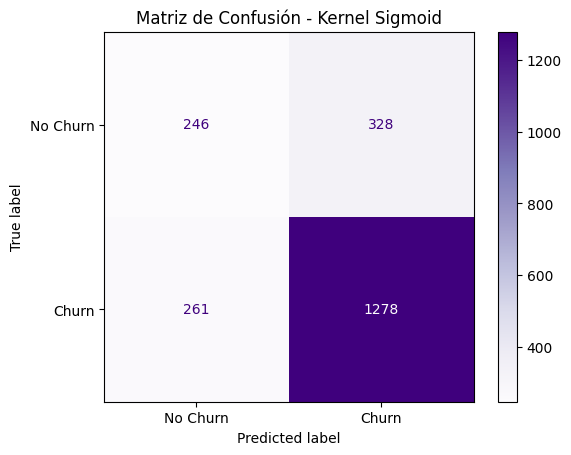

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_sigmoid,
    display_labels=['No Churn', 'Churn'],
    cmap='Purples'
)
plt.title("Matriz de Confusión - Kernel Sigmoid")
plt.show()

In [ ]:
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]

print("Mejores características seleccionadas por SelectKBest:")
print(selected_features.tolist())

Mejores características seleccionadas por SelectKBest:
['tenure', 'InternetService_Fiber optic', 'OnlineSecurity_No', 'OnlineBackup_No', 'DeviceProtection_No', 'TechSupport_No', 'StreamingMovies_No internet service', 'Contract_Month-to-month', 'Contract_Two year', 'PaymentMethod_Electronic check']


podemos observar que baja la presición del modelo, pero esto es a que al momento de eliminar características, estas si aportaban al modelo y al perderlas el modelo da una precisión menor. Pero es un modelo mas liviano.